In [90]:
%matplotlib widget

# Planck spectroscopy

The goal of this Notebook is to present the measurements done to calibrate the signal output line of the LKIPA measurement setup, which is presented in the next figure.

The amplifiers on the output line add classical noise which ruins the possible quantum correlations generated by the JPA. Given the gain ($G$) and added noise ($\bar{n}$) of the amplifiers, the quantum statistics in the covariance matrix can be reconstructed.

In order to get $G$ and $\bar{n}$ we measure the noise power (Johnson-Nyquist noise) emitted by the $20$ dB attenuator in the mixing chamber as a function of temperature. 

The power spectral density emitted from a matched resistor ($R=50 \; \Omega$) as a function of temperature is:

$$ P = \dfrac{hf}{2} \text{coth} \left( \dfrac{hf}{2k_BT} \right).$$

As mentioned, our amplification chain scales this noise by $G$ and adds an average number of photons $\bar{n}$ 

$$ P' = G \dfrac{hf}{2} \left[ \text{coth} \left( \dfrac{hf}{2k_BT} \right) + 2\bar{n} + 1 \right].$$

In terms of the voltage variance over a measurement bandwith ($\Delta$) we have:

$$ \left< V^2 \right> = 4 \Delta R P = 2 \Delta G hf R \left[ \text{coth} \left( \dfrac{hf}{2k_BT} \right) + 2\bar{n} + 1 \right].$$

In [91]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import h5py
import os
import ipywidgets as widgets
import pandas as pd
import csv
import warnings

from tqdm import tqdm
from datetime import datetime
from scipy.constants import Planck, Boltzmann
from scipy.optimize import curve_fit
from scipy.odr import ODR, Model, Data, RealData

warnings.filterwarnings("ignore", category=DeprecationWarning) 

plt.rcParams['axes.formatter.useoffset'] = False
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['font.size'] = 20
plt.rcParams['legend.fontsize'] = 16
plt.rcParams['legend.frameon'] = False

plt.rcParams["font.weight"] = "normal"
plt.rcParams["font.family"] = "serif"

In [92]:
# Thermal noise function for curve_fit fit
def thermal_noise_func(temperature, gain_signal, ns, f_signal, df):
    
    # transmission line impedence
    Zc = 50

    # signal gain in linear scale
    Gs = 10 ** np.abs(gain_signal / 10)

    # conversion factor
    factor_signal = 2 * Zc * Planck * f_signal * df * Gs

    # thermal noise V²
    V2 = factor_signal * (
        1 / np.tanh(Planck * f_signal / (2 * Boltzmann * temperature * 1e-3))
        + (2 * ns + 1)
    ) * 1e12

    return V2


# Thermal noise function for odr fit
def thermal_noise_func_odr(beta, temperature, f_signal, df):
    
    # transmission line impedence
    Zc = 50

    # signal gain in linear scale
    Gs = 10 ** np.abs(beta[0] / 10)

    # conversion factor
    factor_signal = 2 * Zc * Planck * f_signal * df * Gs

    # thermal noise V²
    V2 = factor_signal * (
        1 / np.tanh(Planck * f_signal / (2 * Boltzmann * temperature * 1e-3))
        + (2 * beta[1] + 1)
    ) * 1e12

    return V2

## Thermal noise fit

Now we need to transform our raw experimental data from FS to V $^2$. 

To do so, we first need to calibrate Presto's output and input ports using a vector network analyzer.
We obtain the following values:

$$ 0.707 \text{FS$_{out}$} = -16.10 \; \text{dBm}, $$
$$ 0.045858 \text{FS$_{in}$} = -16.10 \; \text{dBm}. $$

We then want a relation between dBFS $_{in}$ and dBm, to later convert it to V $^2$. 
In this regard:

$$ 0.045858 \; \text{FS$_{in}$} \;\; \rightarrow \;\; 20 \text{log}_{10}(0.045858)\; \text{dBFS$_{in}$}= -26.77 \; \text{dBFS$_{in}$} $$

$$ -26.77 \; \text{dBFS$_{in}$} = -16.10 \; \text{dBm} \;\; \rightarrow \;\; 0 \; \text{dBFS$_{in}$} = 10.67 \; \text{dBm} $$

$$ P[\text{dBm}] = P_0[\text{dBm}] + 20 \log{\left( \dfrac{A[\text{FS}]}{A_0[\text{FS}]} \right)}$$

Then to convert from dBm to V $^2$ we just convert to W using:

$$ P[\text{W}] = 10^{(P[dBm]-30)/10}, $$

and then to V $^2$ as:

$$ P[\text{V}^2] = P[\text{W}] \cdot R $$

We then obtain the gain and added number of photons of the amplification chain by fitting the Johnson-Nyquist noise expression to our experimental thermal noise data.

In [93]:
fs_in = 0.0569              # 0.707 FS_out in FS_in

X = (20 *  np.log10(fs_in)) # 0.707 FS_out in dB_in

Y = -14.4                   # 0.707 FS_out in dBm

W = Y - X                   # 0 dB_in in dBW 

Z = (10 ** ((W - 30)/10)) * 50     # 1.000 FS_out in V^2   : this is the conversion factor for usb^2 to V^2 

print(X, Y, W, Z)

-24.89775467209858 -14.4 10.497754672098578 0.5607192570601488


## Error analysis on the calibration data

We measure $N_{pix} = 2.5 \cdot 10^6$ pixels in total, whose mean and standard deviation is given by:

$$ \overline{FS}_{all} = \dfrac{1}{N_{pix}} \sum_i^{N_{pix}} FS_i $$
$$ \sigma_{FS_{all}} = \sqrt{ \dfrac{1}{N_{pix}} \sum_i^{N_{pix}} \left( FS_i - \overline{FS}_{all} \right)^2}$$

The standard deviation of the whole sample is not a good magnitude to characterize the error of the noise. Thus we chunck the data in $N_{chuncks}=1000$ chuncks of $N_{pix,c}=2500$ pixels each. We then calculate the mean and standard deviation of each chunk as:

$$ \overline{FS}_{c} = \dfrac{1}{N_{pix,c}} \sum_i^{N_{pix,c}} FS_i^c $$
$$ \sigma_{FS_{c}} = \sqrt{ \dfrac{1}{N_{pix,c}} \sum_i^{N_{pix,c}} \left( FS_i^c - \overline{FS}_{c} \right)^2}$$

Eventually, we calculate the standard error of the mean as:

$$ \overline{FS} = \dfrac{1}{N_{chuncks}} \sum_c^{N_{chuncks}} \overline{FS}_{c} $$
$$ \sigma_{FS} = \dfrac{1}{\sqrt{N_{chuncks}}} \sum_c^{N_{chunks}} \dfrac{\sigma_{FS}}{N_{chunks}}$$


In [94]:
# Load the raw calibration data 

# Set to True to load and process raw files (takes ~4 hour)
load = False

if load:

    # Load calibration data
    folder = r'D:/Planck LKIPA Cycle 2026-05'
    filenames = sorted(
        (f for f in os.listdir(folder) if f.endswith('.hdf5')),
        key=lambda f: os.path.getmtime(os.path.join(folder, f))
    )
    file_path = [os.path.join(folder, f) for f in filenames]

    # data empty arrays
    noise_fs = np.zeros((len(file_path), 191))
    noise_fs_std = np.zeros_like(noise_fs)
    noise_uV2 = np.zeros_like(noise_fs)
    noise_uV2_std = np.zeros_like(noise_fs)

    noise_fs_i = np.zeros((1000, 191))
    noise_fs_std_i = np.zeros_like(noise_fs_i)
    noise_uV2_i = np.zeros_like(noise_fs_i)
    noise_uV2_std_i = np.zeros_like(noise_fs_i)

    # Temperature arrays (1D: one stable MXC temperature per file)
    temp_arr = np.zeros(len(file_path))
    temp_std_arr = np.zeros_like(temp_arr)

    # Display nice progress bar
    with tqdm(total=len(file_path), ncols=80) as pbar:

        for file_idx, fp in enumerate(file_path):

            pbar.set_description(os.path.basename(fp))
            try:
                hf = h5py.File(fp, 'r')
            except OSError as e:
                print(f'Cannot open: {fp}')
                print(f'  Error: {e}')
                pbar.update(1)
                continue

            with hf as dataset:

                # Navigate HDF5 hierarchy: "Planck Spectroscopy/{myrun}/..."
                sample_grp = dataset["Planck Spectroscopy"]
                myrun = list(sample_grp.keys())[0]
                run_grp = sample_grp[myrun]

                # Integration bandwidth
                fNCO = 4.429e9
                df = 1e3  # Hz, fixed integration bandwidth

                # MXC temperature saved during measurement (mK)
                temp_arr[file_idx] = float(np.real(np.asarray(run_grp['temperature'])))

                # Frequency comb
                freqs = np.asarray(run_grp['freq comb'])
                IF_usb = freqs - fNCO
                IF_lsb = fNCO - freqs
                freq_arr = np.concatenate((np.flipud(IF_lsb[1:]), IF_usb)) + fNCO

                # Raw data
                usb_arr = np.asarray(run_grp['USB'])
                lsb_arr = np.asarray(run_grp['LSB'])
                sb_arr = np.concatenate((np.fliplr(lsb_arr[:,1:]), usb_arr), axis=1)
                Npix = usb_arr.shape[0]

                # Noise power data in uFS^2 (chunked statistics)
                N_chunk = 2500
                i = 0
                for n in range(0, Npix, N_chunk):
                    abs_sq = np.abs(sb_arr[n:n + N_chunk])**2
                    noise_fs_i[i]  = np.mean(abs_sq, axis=0) * 1e12
                    noise_fs_std_i[i] = np.std(abs_sq, axis=0) * 1e12

                    # Noise power in uV^2
                    noise_dBFS     = 10 * np.log10(np.mean(abs_sq, axis=0))
                    noise_dBm      = noise_dBFS + W
                    noise_W        = 10**((noise_dBm - 30) / 10)
                    noise_uV2_i[i] = noise_W * 50 * 1e12

                    # Standard deviation in uV^2
                    noise_dBFS_std = 10 * np.log10(np.std(abs_sq, axis=0))
                    noise_dBm_std = noise_dBFS_std + W
                    noise_W_std = 10**((noise_dBm_std - 30) / 10)
                    noise_V2_std = noise_W_std * 50
                    noise_uV2_std_i[i] = noise_V2_std * 1e12

                    i += 1

                noise_fs[file_idx] = np.mean(noise_fs_i, axis=0)
                noise_fs_std[file_idx] = np.mean(noise_fs_std_i, axis=0) / np.sqrt(1000)
                noise_uV2[file_idx] = np.mean(noise_uV2_i, axis=0)
                noise_uV2_std[file_idx] = np.mean(noise_uV2_std_i, axis=0) / np.sqrt(1000)

            pbar.update(1)

    # Sort by ascending MXC temperature
    temp_idx = np.argsort(temp_arr)
    temp_arr      = temp_arr[temp_idx]
    temp_std_arr  = temp_std_arr[temp_idx]
    noise_fs      = noise_fs[temp_idx]
    noise_fs_std  = noise_fs_std[temp_idx]
    noise_uV2     = noise_uV2[temp_idx]
    noise_uV2_std = noise_uV2_std[temp_idx]

    # Save processed data
    def save_data(folder, file, myrun, freq, intbw,
                  mean_temp, std_temp, mean_fs, std_fs, mean_V2, std_V2):
        if not os.path.isdir(folder):
            os.makedirs(folder)
        with h5py.File(os.path.join(folder, file), 'a') as savefile:
            if myrun in savefile:
                del savefile[myrun]
            savefile.create_dataset('{}/freq arr'.format(myrun),  data=freq,      dtype=float)
            savefile.create_dataset('{}/df'.format(myrun),        data=intbw,     dtype=float)
            savefile.create_dataset('{}/mean temp'.format(myrun), data=mean_temp, dtype=float)
            savefile.create_dataset('{}/std temp'.format(myrun),  data=std_temp,  dtype=float)
            savefile.create_dataset('{}/mean fs'.format(myrun),   data=mean_fs,   dtype=float)
            savefile.create_dataset('{}/std fs'.format(myrun),    data=std_fs,    dtype=float)
            savefile.create_dataset('{}/mean V2'.format(myrun),   data=mean_V2,   dtype=float)
            savefile.create_dataset('{}/std V2'.format(myrun),    data=std_V2,    dtype=float)

    folder_save = r'D:/Planck LKIPA Cycle 2026-05/Planck-Data'
    file_save   = 'planck_2026-05.hdf5'
    myrun       = '2026-05'

    save_data(folder_save, file_save, myrun, freq_arr, df,
              temp_arr, temp_std_arr, noise_fs, noise_fs_std, noise_uV2, noise_uV2_std)

In [95]:
# One-time patch: correct freq arr in HDF5 file using LKIPA fNCO = 4.429e9
# The raw loader used fNCO=4.1e9 (JPA value); this overwrites the saved freq arr.

correct = False

if correct:
    _file_patch = r'D:/Planck LKIPA Cycle 2026-05/Planck-Data/planck_2026-05.hdf5'
    _run_patch  = '2026-05'
    _fNCO       = 4.429e9

    with h5py.File(_file_patch, 'a') as _hf:
        _freq_arr_old = np.asarray(_hf[f'{_run_patch}/freq arr'])
        _N = (_freq_arr_old.size + 1) // 2          # USB half length
        _freqs = _freq_arr_old[_N - 1:]             # recover raw USB comb
        _IF_usb = _freqs - _fNCO
        _IF_lsb = _fNCO - _freqs
        _freq_arr_new = np.concatenate((np.flipud(_IF_lsb[1:]), _IF_usb)) + _fNCO
        del _hf[f'{_run_patch}/freq arr']
        _hf.create_dataset(f'{_run_patch}/freq arr', data=_freq_arr_new, dtype=float)

    print(f'freq arr patched: {_freq_arr_new.size} points, '
        f'{_freq_arr_new[0]/1e9:.4f} – {_freq_arr_new[-1]/1e9:.4f} GHz')

In [96]:
# Load processed calibration data

file = r'D:/Planck LKIPA Cycle 2026-05/Planck-Data/planck_2026-05.hdf5'
run = '2026-05'
idx_str = '{}'.format(run)

with h5py.File(file, 'r') as dataset:

    # Noise power data in uFS2 * gain_magnitude 
    noise_fs     = np.asarray(dataset[idx_str]['mean fs'])
    noise_fs_std = np.asarray(dataset[idx_str]['std fs'])

    # Noise power data in uV2
    noise_uV2     = np.asarray(dataset[idx_str]['mean V2'])
    noise_uV2_std = np.asarray(dataset[idx_str]['std V2'])

    # MXC temperatures (1D array, one value per file)
    temp_arr     = np.asarray(dataset[idx_str]['mean temp'])
    temp_std_arr = np.asarray(dataset[idx_str]['std temp'])

    # Frequencies
    freq_arr = np.asarray(dataset[idx_str]['freq arr'])

    # Integration bandwidth
    df = np.asarray(dataset[idx_str]['df'])


# Number of temperatures and frequencies
nr_temp = len(temp_arr)
nr_freq = len(freq_arr)

# Conversion factor from FS to V2
factor = np.mean(noise_uV2 / noise_fs)
factor_out = 0.2216

print((factor))   

0.5607192570601488


## Fit, Gain, and Added Photons

c:\Users\Admin\Desktop\Jai Data\venv\Lib\site-packages\scipy\odr\_odrpack.py:422: RuntimeWarning: divide by zero encountered in divide
  return 1./np.power(sd, 2)


interactive(children=(IntSlider(value=0, description='freq ind', max=189), Output()), _dom_classes=('widget-in…

<function __main__.plot_fit(freq_idx_)>

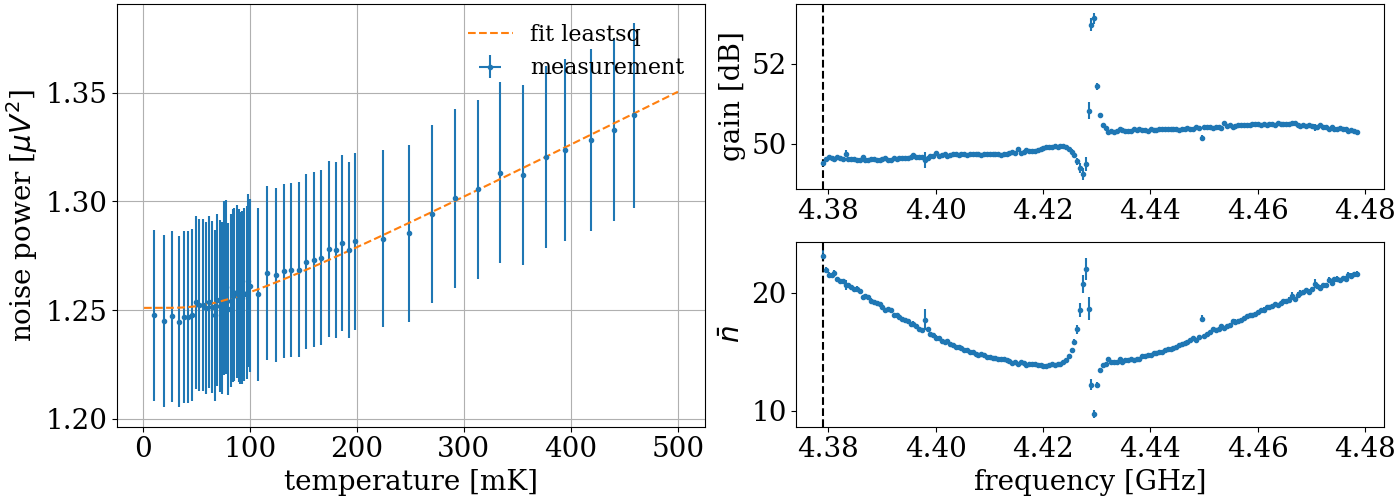

In [97]:
# Thermal noise fit

# Initial guess for fit
G0 = 55
n0 = 5

# initialize empty arrays
gain_arr = np.zeros_like(freq_arr)
gain_std_arr = np.zeros_like(gain_arr)
nbar_arr = np.zeros_like(gain_arr)
nbar_std_arr = np.zeros_like(gain_arr)

# Empty arrays for odr optimization
param = np.zeros((len(gain_arr), 2))
param_std = np.zeros_like(param)

# mixing chamber temperature
temp_mxc = temp_arr
temp_mxc_std = temp_std_arr

for freq_idx, freq_val in enumerate(freq_arr):
    
    # Fit to temperature data using odr
    data = RealData(temp_mxc, noise_uV2[:, freq_idx], temp_mxc_std, noise_uV2_std[:, freq_idx])
    model = Model(lambda beta, temp_mxc: thermal_noise_func_odr(beta, temp_mxc, freq_val, df))
    odr = ODR(data, model, [G0, n0])
    
    # least squares optimization
    odr.set_job(fit_type=2)
    output = odr.run()
    
    # Gain and added noise using leastsq optimization
    gain_arr[freq_idx] = output.beta[0]
    gain_std_arr[freq_idx] = output.sd_beta[0]
    nbar_arr[freq_idx] = output.beta[1]
    nbar_std_arr[freq_idx] = output.sd_beta[1]
    
    # odr (orthogonal distance regression) optimization
    odr.set_job(fit_type=0)
    output = odr.run()
    
    # Gain and added noise using odr optimization
    param[freq_idx] = output.beta
    param_std[freq_idx] = output.sd_beta
    


# Plot — create figure once, update axes on each slider change
fig9 = plt.figure(figsize=(14, 5))
gs9 = gridspec.GridSpec(2, 2, figure=fig9)
ax9 = fig9.add_subplot(gs9[:, 0])
ax9_gain = fig9.add_subplot(gs9[0, 1])
ax9_n = fig9.add_subplot(gs9[1, 1])
    # ax_pn.set_xlim(10, 100)
    # ax_pn.set_ylim(18, 22)
def plot_fit(freq_idx_):
    
    gain_val = gain_arr[freq_idx_]  # Gain at a given frequency
    nbar_val = nbar_arr[freq_idx_]  # Added noise at a given freq
    freq_val = freq_arr[freq_idx_]  # Given frequency
    
    # Temperature range for fitting
    temp_fit = np.linspace(1, 500, 1000)    
    noise_fit = thermal_noise_func_odr([gain_val, nbar_val], temp_fit, freq_val, df)  # leastsq
    noise_fit_odr = thermal_noise_func_odr(param[freq_idx_], temp_fit, freq_val, df)  # odr
    
    ax9.cla()
    ax9_gain.cla()
    ax9_n.cla()
    
    # Experimental data
    ax9.errorbar(temp_mxc, 
                noise_uV2[:, freq_idx_], 
                xerr=temp_mxc_std,
                yerr=noise_uV2_std[:, freq_idx_], 
                fmt='.', 
                label='measurement',
               )
    # leastsq fit
    ax9.plot(temp_fit, noise_fit, '--', label='fit leastsq')
    # odr fit
    # ax9.plot(temp_fit, noise_fit_odr, '--', label='fit odr')
    ax9.set_xlabel('temperature [mK]')
    ax9.set_ylabel('noise power [$\\mu V^2$]')
    ax9.legend()
    ax9.grid()
    
    # Gain
    ax9_gain.errorbar(freq_arr[:-1]/1e9, gain_arr[:-1], yerr=gain_std_arr[:-1], fmt='.', label='leastsq')
    # ax9_gain.errorbar(freq_arr[:-1]/1e9, param[:-1, 0], yerr=param_std[:-1, 0], fmt='.', label='odr')
    ax9_gain.axvline(freq_val/1e9, color='black', linestyle='--')
    ax9_gain.set_ylabel('gain [dB]')
    
    # Added noise
    ax9_n.errorbar(freq_arr[:-1]/1e9, nbar_arr[:-1], yerr=nbar_std_arr[:-1], fmt='.', label='leastsq')
    # ax9_n.errorbar(freq_arr[:-1]/1e9, param[:-1, 1], yerr=param_std[:-1, 1], fmt='.', label='odr')
    ax9_n.axvline(freq_val/1e9, color='black', linestyle='--')
    ax9_n.set_xlabel(r'frequency [GHz]')
    ax9_n.set_ylabel(r'$\bar{n}$')

    fig9.canvas.draw_idle()

    
# Interactive layout  
widgets.interact(plot_fit,
                 freq_idx_=widgets.IntSlider(min=0,
                                             max=len(freq_arr)-2,
                                             step=1,
                                             description='freq ind',
                                             )
                )

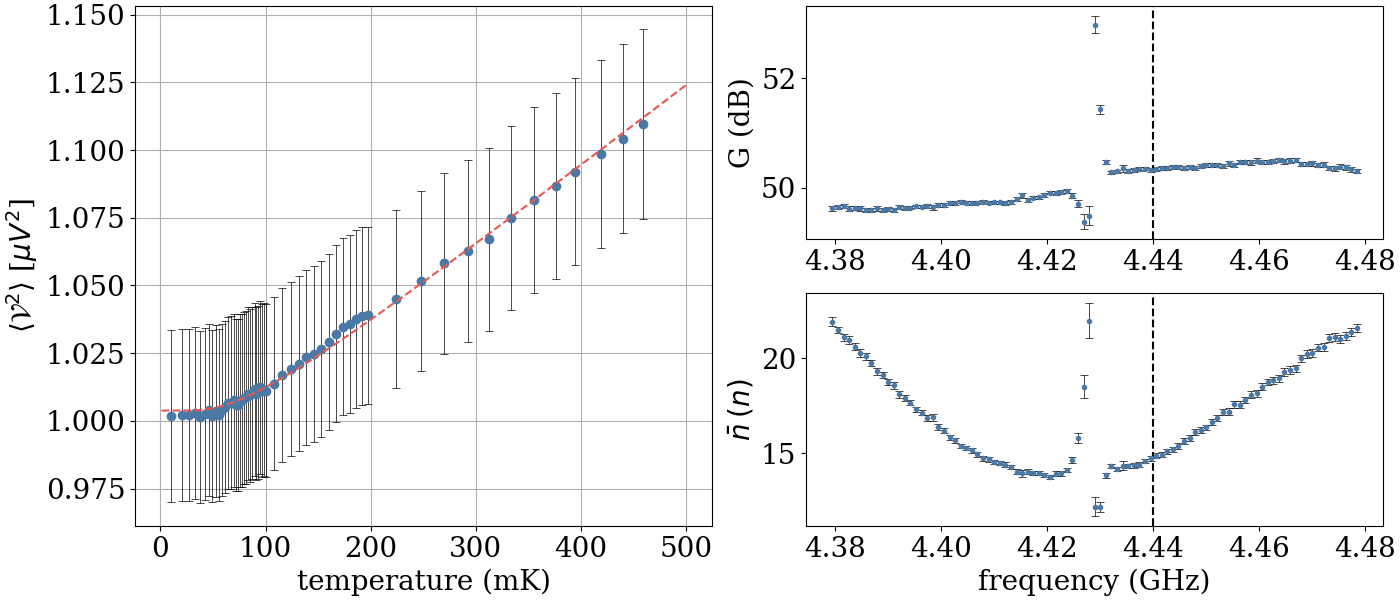

In [98]:
def plot_fit_single(freq_idx_):
    
    gain_val = gain_arr[freq_idx_]  # Gain at a given frequency
    nbar_val = nbar_arr[freq_idx_]  # Added noise at a given freq
    freq_val = freq_arr[freq_idx_]  # Given frequency
    
    # Temperature range for fitting
    temp_fit = np.linspace(1, 500, 1000)    
    noise_fit = thermal_noise_func_odr([gain_val, nbar_val], temp_fit, freq_val, df)  # leastsq
    
    # Plot fits
    fig = plt.figure(figsize=(14, 6))
    gs = gridspec.GridSpec(2, 2, figure=fig)
    ax = fig.add_subplot(gs[:, 0])
    
    # Experimental data
    ax.errorbar(temp_mxc, 
                noise_uV2[:, freq_idx_], 
                xerr=temp_mxc_std,
                yerr=noise_uV2_std[:, freq_idx_], 
                fmt='o',
                mfc='#4B79A5',
                c='#4B79A5',
                capsize=3,
                ecolor='black', 
                elinewidth=0.5,
                capthick=0.5,
               )
    # leastsq fit
    ax.plot(temp_fit, noise_fit, '--', c='#ED564E', zorder=2.1)

    ax.set_xlabel('temperature (mK)')
    ax.set_ylabel(r'$\langle \mathcal{V}^2 \rangle$ [$\mu V^2$]')
    ax.grid()
    # ax.legend()
    
    # Gain
    ax_gain = fig.add_subplot(gs[0, 1])
    ax_gain.errorbar(freq_arr[1::2]/1e9, gain_arr[1::2], yerr=gain_std_arr[1::2], fmt='.', c='#4B79A5', capsize=3, ecolor='black', 
                elinewidth=0.5,
                capthick=0.5)
    ax_gain.axvline(freq_val/1e9, color='black', linestyle='--')
    ax_gain.set_ylabel(r'G (dB)')
    
    # Added noise
    ax_n = fig.add_subplot(gs[1, 1])
    ax_n.errorbar(freq_arr[1::2]/1e9, nbar_arr[1::2], yerr=nbar_std_arr[1::2], fmt='.', c='#4B79A5', capsize=3, ecolor='black', 
                elinewidth=0.5,
                capthick=0.5)
    ax_n.axvline(freq_val/1e9, color='black', linestyle='--', zorder=1.9)
    ax_n.set_xlabel(r'frequency (GHz)')
    ax_n.set_ylabel(r'$\bar{n} \: (n)$')

plot_fit_single(freq_idx_=116)


## Noise power in Photon Number

interactive(children=(IntSlider(value=0, description='freq ind', max=189), Output()), _dom_classes=('widget-in…

<function __main__.plot_photon_number(freq_idx_)>

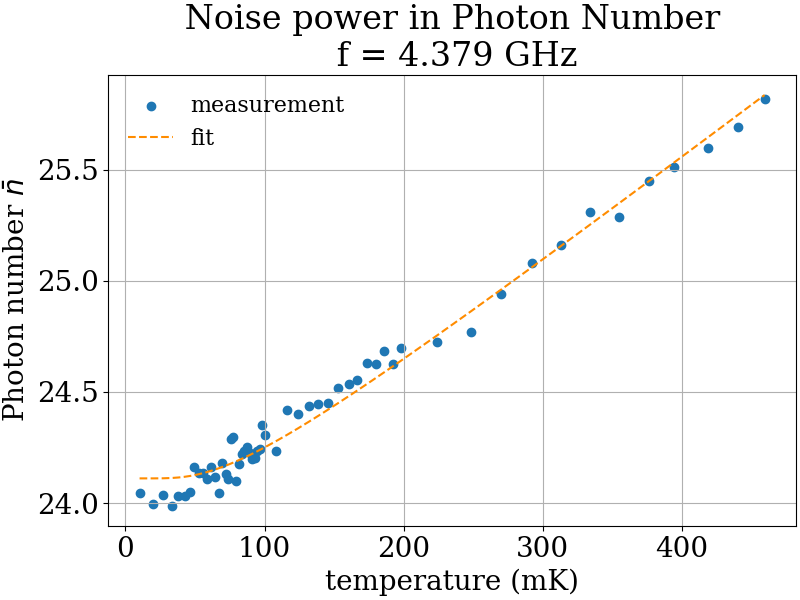

In [99]:
# Slider plot: noise power in photon number
fig_pn = plt.figure(figsize=(8, 6))
ax_pn = fig_pn.add_subplot(111)

# Parameters for conversion
z_c = 50  #ohms
bw = 1e3  # Hz, integration bandwidth

# Gain in linear scale
def gain_linear(gain_dB):
    return 10 ** (gain_dB / 10)

gain_magnitude = gain_linear(gain_arr)  # Convert gain from dB to linear scale
scale    = 4 * z_c * Planck * bw * 1e12   # Scale factor for converting V^2 to photons

# Convert noise power from uV^2 to number of photons using the relation:
noise_photons = noise_uV2 / (scale * freq_arr * gain_magnitude )  # photons = V^2 / (2 * Zc * hbar * f * df)


def plot_photon_number(freq_idx_):

    gain_val = gain_arr[freq_idx_]
    nbar_val = nbar_arr[freq_idx_]
    freq_val = freq_arr[freq_idx_]


    temp_fit  = temp_mxc
    noise_fit = thermal_noise_func_odr([gain_val, nbar_val], temp_fit, freq_val, df) / (scale * freq_val * gain_linear(gain_val))

    print(f'Gain: {gain_val:.2f} dB, Added noise: {nbar_val:.2f} photons at f = {freq_val/1e9:.3f} GHz')

    ax_pn.cla()

    ax_pn.scatter(temp_mxc,
                   noise_photons[:, freq_idx_],
                   label='measurement',
                  )
    ax_pn.plot(temp_fit, noise_fit, '--', label='fit', color = 'darkorange')
    ax_pn.set_xlabel('temperature (mK)')
    ax_pn.set_ylabel(r'Photon number $\bar{n}$')
    ax_pn.set_title(f' Noise power in Photon Number \n f = {freq_val/1e9:.3f} GHz')
    # ax_pn.set_xlim(10, 100)
    # ax_pn.set_ylim(18, 22)
    ax_pn.legend()
    ax_pn.grid()

    fig_pn.canvas.draw_idle()

widgets.interact(plot_photon_number,
                 freq_idx_=widgets.IntSlider(min=0,
                                             max=len(freq_arr)-2,
                                             step=1,
                                             description='freq ind',
                                             )
                )


## Segregate temperature points based on which branch they lie on

In [100]:
# Frequency index for best decision boundary
f_decision_idx = 12

# Decision boundary: noise power in photons at f_decision_idx
gain_val = gain_arr[f_decision_idx]
nbar_val = nbar_arr[f_decision_idx]
freq_val = freq_arr[f_decision_idx]

noise_fit = thermal_noise_func_odr([gain_val, nbar_val], temp_mxc, freq_val, df) / (scale * freq_val * gain_linear(gain_val))

t_high = []
t_low = []

for temp_idx, temp_val in enumerate(temp_mxc):
    if noise_photons[temp_idx, f_decision_idx] > noise_fit[temp_idx]:
        t_high.append(temp_idx)

    else:
        t_low.append(temp_idx)

## Create noise power arrays for each branch

In [101]:
# Upper branch
noise_uV2_high = noise_uV2[t_high, :]

# initialize empty arrays
gain_high_arr = np.zeros_like(freq_arr)
gain_high_std_arr = np.zeros_like(gain_high_arr)
nbar_high_arr = np.zeros_like(gain_high_arr)
nbar_high_std_arr = np.zeros_like(gain_high_arr)

# Empty arrays for odr optimization
param = np.zeros((len(gain_high_arr), 2))
param_std = np.zeros_like(param)

# mixing chamber temperature
temp_mxc_high = temp_arr[t_high]
temp_mxc_std = temp_std_arr[t_high]

for freq_idx, freq_val in enumerate(freq_arr):
    
    # Fit to temperature data using odr
    data = RealData(temp_mxc_high, noise_uV2_high[:, freq_idx], temp_mxc_std, noise_uV2_std[:, freq_idx])
    model = Model(lambda beta, temp_mxc: thermal_noise_func_odr(beta, temp_mxc, freq_val, df))
    odr = ODR(data, model, [G0, n0])
    
    # least squares optimization
    odr.set_job(fit_type=2)
    output = odr.run()
    
    # Gain and added noise using leastsq optimization
    gain_high_arr[freq_idx] = output.beta[0]
    gain_high_std_arr[freq_idx] = output.sd_beta[0]
    nbar_high_arr[freq_idx] = output.beta[1]
    nbar_high_std_arr[freq_idx] = output.sd_beta[1]
    
    # odr (orthogonal distance regression) optimization
    odr.set_job(fit_type=0)
    output = odr.run()
    
    # Gain and added noise using odr optimization
    param[freq_idx] = output.beta
    param_std[freq_idx] = output.sd_beta

# In photon number
noise_photons_high = noise_uV2_high / (scale * freq_arr * gain_linear(gain_high_arr))
# noise_photons_fit_high = noise_fit_high / (scale * freq_arr * gain_linear(gain_high_arr))


# Lower branch
noise_uV2_low = noise_uV2[t_low, :]

gain_low_arr     = np.zeros_like(freq_arr)
gain_low_std_arr = np.zeros_like(gain_low_arr)
nbar_low_arr     = np.zeros_like(gain_low_arr)
nbar_low_std_arr = np.zeros_like(gain_low_arr)

temp_mxc_low     = temp_arr[t_low]
temp_mxc_low_std = temp_std_arr[t_low]

for freq_idx, freq_val in enumerate(freq_arr):

    data  = RealData(temp_mxc_low, noise_uV2_low[:, freq_idx], temp_mxc_low_std, noise_uV2_std[t_low, freq_idx])
    model = Model(lambda beta, t: thermal_noise_func_odr(beta, t, freq_val, df))
    odr   = ODR(data, model, [G0, n0])
    odr.set_job(fit_type=2)
    output = odr.run()

    gain_low_arr[freq_idx]     = output.beta[0]
    gain_low_std_arr[freq_idx] = output.sd_beta[0]
    nbar_low_arr[freq_idx]     = output.beta[1]
    nbar_low_std_arr[freq_idx] = output.sd_beta[1]

noise_photons_low = noise_uV2_low / (scale * freq_arr * gain_linear(gain_low_arr))

interactive(children=(IntSlider(value=0, description='freq ind', max=189), Output()), _dom_classes=('widget-in…

<function __main__.plot_both_branches(freq_idx_)>

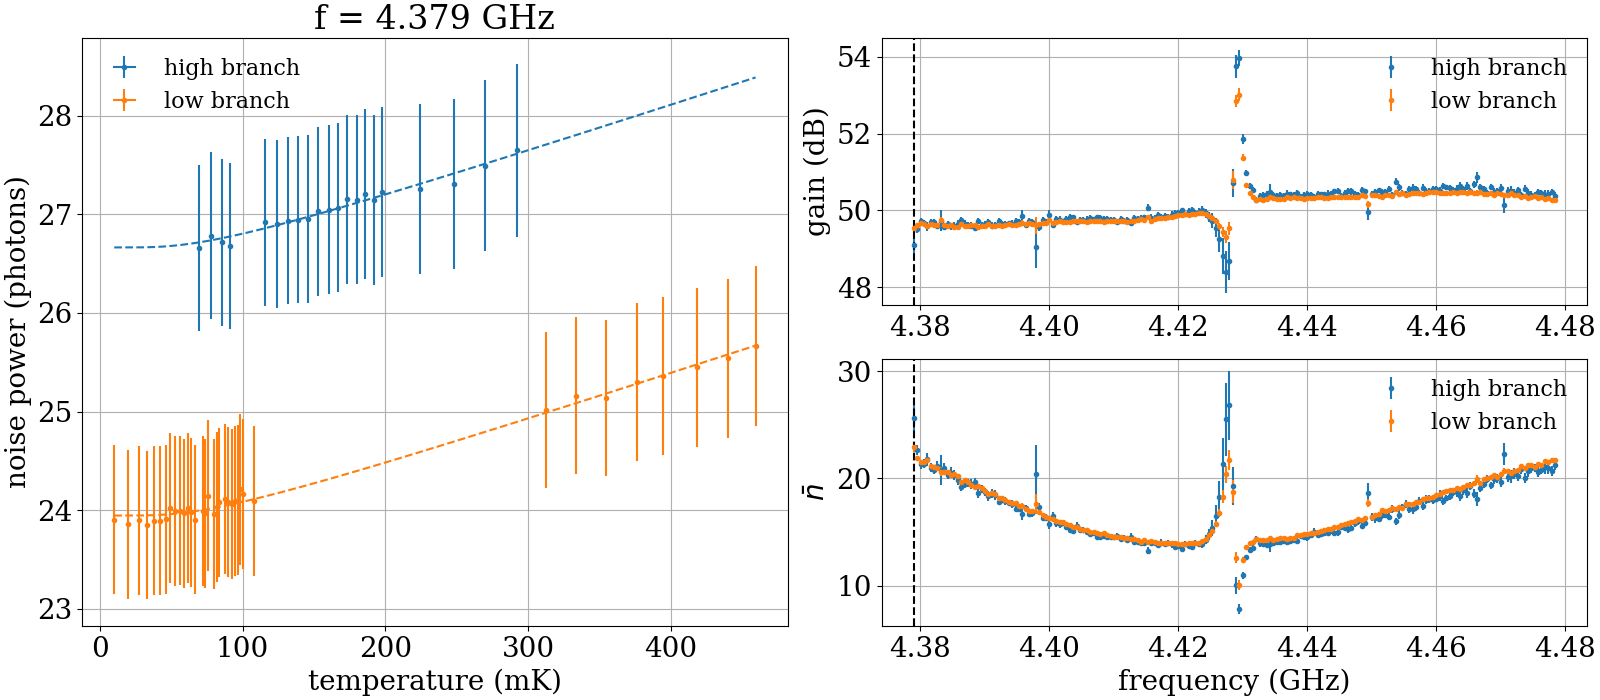

In [102]:
# Combined slider: both branches — left: noise vs temp, right top: gain, right bottom: nbar
fig_both = plt.figure(figsize=(16, 7))
gs_both  = gridspec.GridSpec(2, 2, figure=fig_both)
ax_noise = fig_both.add_subplot(gs_both[:, 0])   # full left: noise vs temp
ax_gain  = fig_both.add_subplot(gs_both[0, 1])   # top right: gain vs freq
ax_nbar  = fig_both.add_subplot(gs_both[1, 1])   # bottom right: nbar vs freq

def plot_both_branches(freq_idx_):

    freq_val = freq_arr[freq_idx_]

    # High branch
    gain_h     = gain_high_arr[freq_idx_]
    scale_h    = scale * freq_val * gain_linear(gain_h)
    temp_fit_h = np.linspace(temp_mxc.min(), temp_mxc.max(), 1000)
    fit_h      = thermal_noise_func_odr([gain_h, nbar_high_arr[freq_idx_]], temp_fit_h, freq_val, df) / scale_h

    # Low branch
    gain_l     = gain_low_arr[freq_idx_]
    scale_l    = scale * freq_val * gain_linear(gain_l)
    temp_fit_l = np.linspace(temp_mxc.min(), temp_mxc.max(), 1000)
    fit_l      = thermal_noise_func_odr([gain_l, nbar_low_arr[freq_idx_]], temp_fit_l, freq_val, df) / scale_l

    ax_noise.cla(); ax_gain.cla(); ax_nbar.cla()

    # Left: noise vs temperature, both branches
    ax_noise.errorbar(temp_mxc_high, noise_photons_high[:, freq_idx_],
                      xerr=temp_mxc_std, yerr=noise_uV2_std[t_high, freq_idx_] / scale_h,
                      fmt='.', color='C0', label='high branch')
    ax_noise.plot(temp_fit_h, fit_h, '--', color='C0')
    ax_noise.errorbar(temp_mxc_low, noise_photons_low[:, freq_idx_],
                      xerr=temp_mxc_low_std, yerr=noise_uV2_std[t_low, freq_idx_] / scale_l,
                      fmt='.', color='C1', label='low branch')
    ax_noise.plot(temp_fit_l, fit_l, '--', color='C1')
    ax_noise.set_xlabel('temperature (mK)')
    ax_noise.set_ylabel('noise power (photons)')
    ax_noise.set_title(f'f = {freq_val/1e9:.3f} GHz')
    ax_noise.grid()
    ax_noise.legend()

    # Top right: gain vs frequency, both branches
    ax_gain.errorbar(freq_arr[:-1]/1e9, gain_high_arr[:-1], yerr=gain_high_std_arr[:-1],
                     fmt='.', color='C0', label='high branch')
    ax_gain.errorbar(freq_arr[:-1]/1e9, gain_low_arr[:-1], yerr=gain_low_std_arr[:-1],
                     fmt='.', color='C1', label='low branch')
    ax_gain.axvline(freq_val/1e9, color='black', linestyle='--')
    ax_gain.set_ylabel('gain (dB)')
    ax_gain.legend()
    ax_gain.grid()

    # Bottom right: nbar vs frequency, both branches
    ax_nbar.errorbar(freq_arr[:-1]/1e9, nbar_high_arr[:-1], yerr=nbar_high_std_arr[:-1],
                     fmt='.', color='C0', label='high branch')
    ax_nbar.errorbar(freq_arr[:-1]/1e9, nbar_low_arr[:-1], yerr=nbar_low_std_arr[:-1],
                     fmt='.', color='C1', label='low branch')
    ax_nbar.axvline(freq_val/1e9, color='black', linestyle='--')
    ax_nbar.set_xlabel('frequency (GHz)')
    ax_nbar.set_ylabel(r'$\bar{n}$')
    ax_nbar.legend()
    ax_nbar.grid()

    print(f'Gain: {gain_high_arr[freq_idx_]:.2f} dB, Added noise: {nbar_high_arr[freq_idx_]:.2f} photons at f = {freq_val/1e9:.3f} GHz for HIGH BRANCH')
    print(f'Gain: {gain_low_arr[freq_idx_]:.2f} dB, Added noise: {nbar_low_arr[freq_idx_]:.2f} photons at f = {freq_val/1e9:.3f} GHz for LOW BRANCH')
    fig_both.canvas.draw_idle()

widgets.interact(plot_both_branches,
                 freq_idx_=widgets.IntSlider(min=0,
                                             max=len(freq_arr)-2,
                                             step=1,
                                             description='freq ind',
                                             )
                )


C:\Users\Admin\AppData\Local\Temp\ipykernel_22848\2112125443.py:29: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


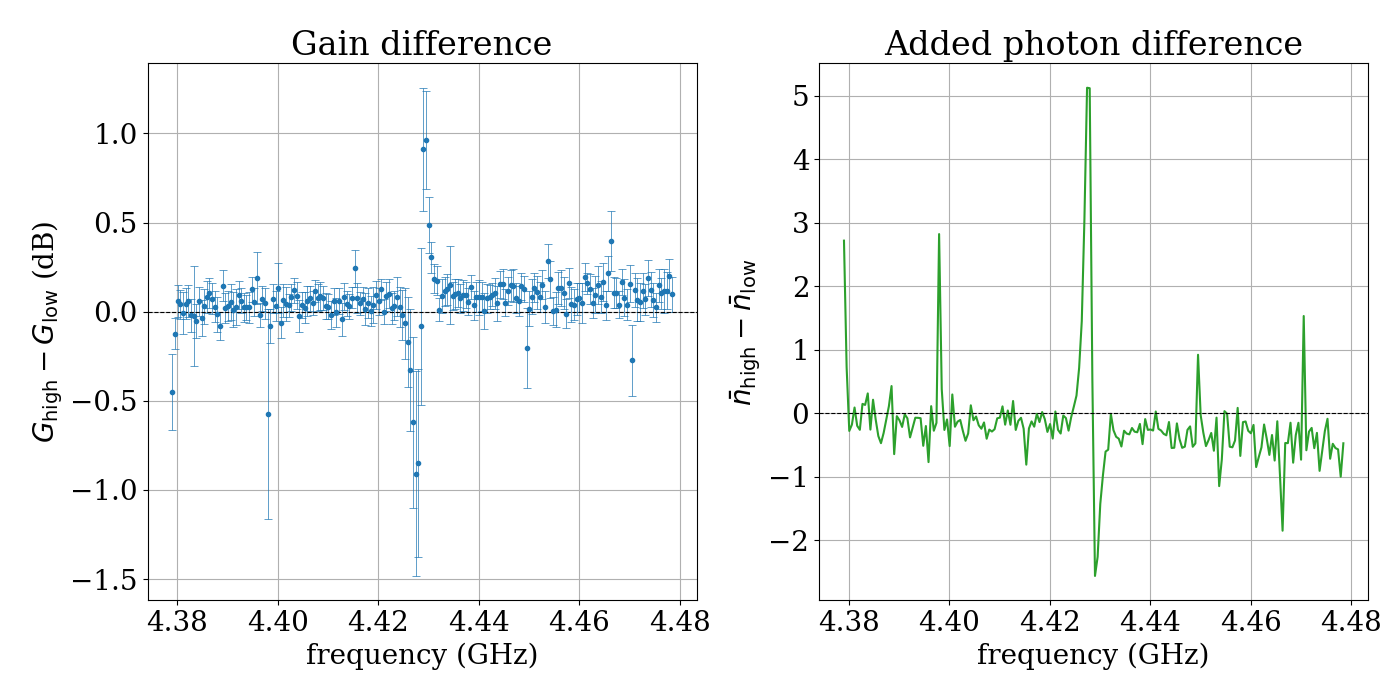

In [103]:
# Gain difference: high branch minus low branch as a function of frequency
fig_diff, ax_diff = plt.subplots(figsize=(14, 7), ncols=2)

ax_gdiff, ax_nbar_diff = ax_diff

# Plot 1: gain difference
gain_diff     = gain_high_arr[:-1] - gain_low_arr[:-1]
gain_diff_std = np.sqrt(gain_high_std_arr[:-1]**2 + gain_low_std_arr[:-1]**2)

ax_gdiff.errorbar(freq_arr[:-1]/1e9, gain_diff, yerr=gain_diff_std,
                  fmt='.', capsize=3, elinewidth=0.5, capthick=0.5)
ax_gdiff.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax_gdiff.set_xlabel('frequency (GHz)')
ax_gdiff.set_ylabel(r'$G_{\rm high} - G_{\rm low}$ (dB)')
ax_gdiff.set_title('Gain difference')
ax_gdiff.grid()

# Plot 2: photon number difference
nbar_diff = nbar_high_arr[:-1] - nbar_low_arr[:-1]

ax_nbar_diff.plot(freq_arr[:-1]/1e9, nbar_diff, ls='-',color='C2')
ax_nbar_diff.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax_nbar_diff.set_xlabel('frequency (GHz)')
ax_nbar_diff.set_ylabel(r'$\bar{n}_{\rm high} - \bar{n}_{\rm low}$')
ax_nbar_diff.set_title('Added photon difference')
ax_nbar_diff.grid()


plt.tight_layout()
plt.show()


interactive(children=(IntSlider(value=0, description='freq ind', max=189), Output()), _dom_classes=('widget-in…

<function __main__.plot_all_fits(freq_idx_)>

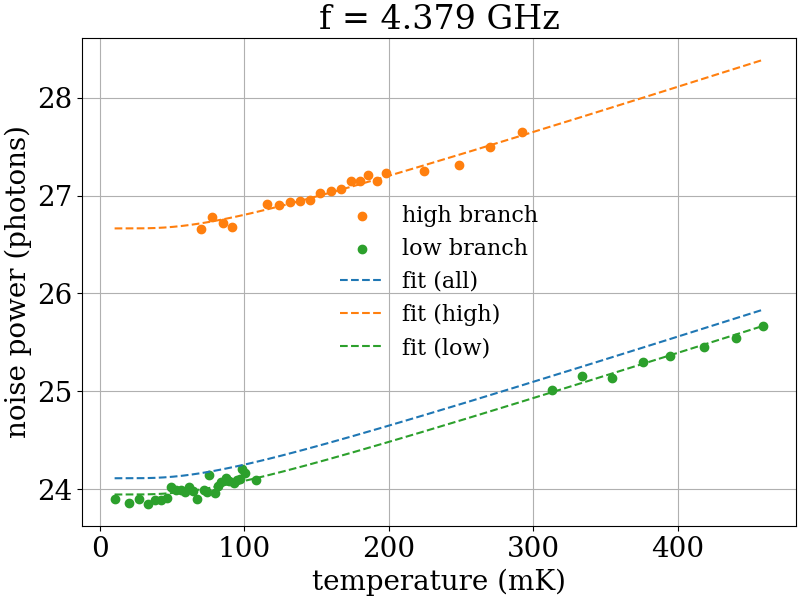

In [104]:
# Slider plot: all three fit curves in photon number
fig_all = plt.figure(figsize=(8, 6))
ax_all  = fig_all.add_subplot(111)

def plot_all_fits(freq_idx_):

    freq_val = freq_arr[freq_idx_]

    # All-data fit
    gain_all  = gain_arr[freq_idx_]
    scale_all = scale * freq_val * gain_linear(gain_all)
    temp_fit_all = np.linspace(temp_mxc.min(), temp_mxc.max(), 1000)
    fit_all  = thermal_noise_func_odr([gain_all, nbar_arr[freq_idx_]], temp_fit_all, freq_val, df) / scale_all

    # High branch fit
    gain_h   = gain_high_arr[freq_idx_]
    scale_h  = scale * freq_val * gain_linear(gain_h)
    temp_fit_h = np.linspace(temp_mxc.min(), temp_mxc.max(), 1000)
    fit_h    = thermal_noise_func_odr([gain_h, nbar_high_arr[freq_idx_]], temp_fit_h, freq_val, df) / scale_h

    # Low branch fit
    gain_l   = gain_low_arr[freq_idx_]
    scale_l  = scale * freq_val * gain_linear(gain_l)
    temp_fit_l = np.linspace(temp_mxc.min(), temp_mxc.max(), 1000)
    fit_l    = thermal_noise_func_odr([gain_l, nbar_low_arr[freq_idx_]], temp_fit_l, freq_val, df) / scale_l

    ax_all.cla()

    # Data points
    #ax_all.scatter(temp_mxc,     noise_photons[: , freq_idx_], color='C0',  label='all data',   zorder=2)
    ax_all.scatter(temp_mxc_high,     noise_photons_high[:, freq_idx_], color='C1',  label='high branch', zorder=2)
    ax_all.scatter(temp_mxc_low, noise_photons_low[:, freq_idx_],  color='C2',  label='low branch',  zorder=2)

    # Fit curves
    ax_all.plot(temp_fit_all, fit_all, '--', color='C0',  label='fit (all)')
    ax_all.plot(temp_fit_h,   fit_h,   '--', color='C1',  label='fit (high)')
    ax_all.plot(temp_fit_l,   fit_l,   '--', color='C2',  label='fit (low)')

    ax_all.set_xlabel('temperature (mK)')
    ax_all.set_ylabel('noise power (photons)')
    ax_all.set_title(f'f = {freq_val/1e9:.3f} GHz')
    ax_all.legend()
    ax_all.grid()

    fig_all.canvas.draw_idle()

widgets.interact(plot_all_fits,
                 freq_idx_=widgets.IntSlider(min=0,
                                             max=len(freq_arr)-2,
                                             step=1,
                                             description='freq ind',
                                             )
                )


# Save overall gain and photon number data

In [105]:
# Open the save file (.hdf5) in append mode
save = True

if save:
    
    with h5py.File(file, "a") as dataset:

        # String as handles
        gain_data_str = "{}/gain".format(run)
        std_gain_data_str = "{}/std gain".format(run)
        n_data_str = "{}/n".format(run)
        std_n_data_str = "{}/std n".format(run)

        # Write data to datasets
        dataset.create_dataset(gain_data_str, (np.shape(gain_arr)),
                               dtype=float, data=gain_arr)
        dataset.create_dataset(std_gain_data_str, (np.shape(gain_std_arr)),
                               dtype=float, data=gain_std_arr)
        dataset.create_dataset(n_data_str, (np.shape(nbar_arr)),
                               dtype=float, data=nbar_arr)
        dataset.create_dataset(std_n_data_str, (np.shape(nbar_std_arr)),
                               dtype=float, data=nbar_std_arr)


        # Write dataset attributes
        dataset[gain_data_str].attrs["Unit"] = "dB"
        dataset[std_gain_data_str].attrs["Unit"] = "dB"
        dataset[n_data_str].attrs["Unit"] = "n"
        dataset[std_n_data_str].attrs["Unit"] = "n"

ValueError: Unable to synchronously create dataset (name already exists)